##  Indian Movie Dataset

###
Generate a synthetic dataset of Indian movies including columns such as 'Title', 'Genre', 'Director', 'Year', 'Rating', 'Budget', and 'Revenue' to simulate a realistic scenario for analysis.


In [25]:
import pandas as pd
import numpy as np

print("pandas and numpy libraries imported successfully.")

pandas and numpy libraries imported successfully.


In [26]:
genres = ['Action', 'Drama', 'Comedy', 'Romance', 'Thriller', 'Historical', 'Crime', 'Biopic', 'Musical', 'Fantasy']
directors = ['Rajkumar Hirani', 'Karan Johar', 'Sanjay Leela Bhansali', 'Rohit Shetty', 'Zoya Akhtar', 'Anurag Kashyap', 'SS Rajamouli', 'Mani Ratnam', 'Priyadarshan', 'Gautham Menon']
title_prefixes = ['The', 'My', 'Our', 'A', 'Lost', 'New', 'Eternal', 'Silent', 'Golden', 'Dark']
title_mid_words = ['Journey', 'Love', 'Destiny', 'Secret', 'City', 'Heart', 'Battle', 'Dream', 'Life', 'Story']
title_suffixes = ['of India', 'Reborn', 'Returns', 'Unveiled', 'Forever', 'Begins', 'End', 'Continues', 'Redemption', 'Unfolding']

print("Lists for genres, directors, and movie title components defined.")

Lists for genres, directors, and movie title components defined.


In [27]:
num_movies = 150 # Number of synthetic movies to generate

movies_data = []
for i in range(num_movies):
    # Generate a unique title by combining components and adding an index
    title = f"{np.random.choice(title_prefixes)} {np.random.choice(title_mid_words)} {np.random.choice(title_suffixes)} {i+1:03d}"
    genre = np.random.choice(genres)
    director = np.random.choice(directors)
    year = np.random.randint(2000, 2024) # Years between 2000 and 2023
    rating = np.round(np.random.uniform(1.0, 10.0), 1) # Rating between 1.0 and 10.0

    budget_crores = np.random.randint(10, 301) # Budget between 10 and 300 crores

    # Revenue generally higher than budget, with some losses
    if np.random.rand() < 0.8: # 80% chance of profit
        revenue_crores = budget_crores + np.random.randint(5, 500)
    else: # 20% chance of loss
        revenue_crores = budget_crores - np.random.randint(1, budget_crores // 2) # Ensure revenue is not negative
        revenue_crores = max(0, revenue_crores) # Ensure revenue is at least 0

    movies_data.append({
        'Title': title,
        'Genre': genre,
        'Director': director,
        'Year': year,
        'Rating': rating,
        'Budget': budget_crores,
        'Revenue': revenue_crores
    })

df_movies = pd.DataFrame(movies_data)

print(f"Generated {len(df_movies)} synthetic movie entries.")
print("Displaying the first 5 rows of the generated DataFrame:")
print(df_movies.head())


Generated 150 synthetic movie entries.
Displaying the first 5 rows of the generated DataFrame:
                       Title     Genre         Director  Year  Rating  Budget  \
0  Golden Story Unveiled 001     Drama      Mani Ratnam  2018     9.5      82   
1      A Battle Unveiled 002   Fantasy    Gautham Menon  2014     9.0     243   
2    My Destiny Unveiled 003     Crime     Priyadarshan  2022     6.7     172   
3   Golden Life of India 004    Biopic  Rajkumar Hirani  2018     2.1      94   
4        My Heart Begins 005  Thriller      Zoya Akhtar  2000     7.5     109   

   Revenue  
0      369  
1      699  
2      103  
3      165  
4      294  


## Load and Inspect Data




In [28]:
print("First 5 rows of the DataFrame:")
print(df_movies.head())

print("\nDataFrame Information:")
df_movies.info()

print("\nMissing values per column:")
print(df_movies.isnull().sum())

First 5 rows of the DataFrame:
                       Title     Genre         Director  Year  Rating  Budget  \
0  Golden Story Unveiled 001     Drama      Mani Ratnam  2018     9.5      82   
1      A Battle Unveiled 002   Fantasy    Gautham Menon  2014     9.0     243   
2    My Destiny Unveiled 003     Crime     Priyadarshan  2022     6.7     172   
3   Golden Life of India 004    Biopic  Rajkumar Hirani  2018     2.1      94   
4        My Heart Begins 005  Thriller      Zoya Akhtar  2000     7.5     109   

   Revenue  
0      369  
1      699  
2      103  
3      165  
4      294  

DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Title     150 non-null    object 
 1   Genre     150 non-null    object 
 2   Director  150 non-null    object 
 3   Year      150 non-null    int64  
 4   Rating    150 non-null    float64
 5 

## Clean Data

###
Handle missing values by either dropping rows or filling them with appropriate strategies (e.g., mean for numerical columns, mode for categorical columns) to ensure data quality for analysis.


In [29]:
print("Re-verifying missing values:")
print(df_movies.isnull().sum())

print("\nNo missing values found, so no action is required for missing data.")

print("\nChecking for duplicate rows:")
duplicate_rows = df_movies.duplicated().sum()
if duplicate_rows > 0:
    print(f"Found {duplicate_rows} duplicate rows. Removing duplicates...")
    df_movies.drop_duplicates(inplace=True)
    print("Duplicate rows removed. New DataFrame shape:", df_movies.shape)
else:
    print("No duplicate rows found.")

Re-verifying missing values:
Title       0
Genre       0
Director    0
Year        0
Rating      0
Budget      0
Revenue     0
dtype: int64

No missing values found, so no action is required for missing data.

Checking for duplicate rows:
No duplicate rows found.


## Statistical Analysis of Ratings

###
Compute and display the mean, median, and standard deviation of the 'Rating' column using NumPy functions. Perform similar statistical analysis for 'Budget' and 'Revenue' columns.


In [30]:
print("Statistical Analysis for 'Rating' column:")
print(f"Mean Rating: {np.mean(df_movies['Rating']):.2f}")
print(f"Median Rating: {np.median(df_movies['Rating']):.2f}")
print(f"Standard Deviation of Rating: {np.std(df_movies['Rating']):.2f}")

print("\nStatistical Analysis for 'Budget' column (in Crores):")
print(f"Mean Budget: {np.mean(df_movies['Budget']):.2f}")
print(f"Median Budget: {np.median(df_movies['Budget']):.2f}")
print(f"Standard Deviation of Budget: {np.std(df_movies['Budget']):.2f}")

print("\nStatistical Analysis for 'Revenue' column (in Crores):")
print(f"Mean Revenue: {np.mean(df_movies['Revenue']):.2f}")
print(f"Median Revenue: {np.median(df_movies['Revenue']):.2f}")
print(f"Standard Deviation of Revenue: {np.std(df_movies['Revenue']):.2f}")

Statistical Analysis for 'Rating' column:
Mean Rating: 5.46
Median Rating: 5.50
Standard Deviation of Rating: 2.65

Statistical Analysis for 'Budget' column (in Crores):
Mean Budget: 151.14
Median Budget: 160.00
Standard Deviation of Budget: 81.05

Statistical Analysis for 'Revenue' column (in Crores):
Mean Revenue: 347.76
Median Revenue: 348.00
Standard Deviation of Revenue: 194.45


## Grouped Analysis by Genre and Director

###
Group the DataFrame by 'Genre' and calculate the average 'Rating' for each genre. Similarly, group by 'Director' and compute the average 'Rating' for each director.


In [31]:
print("Calculating average rating by Genre:")
avg_rating_by_genre = df_movies.groupby('Genre')['Rating'].mean().sort_values(ascending=False)
print(avg_rating_by_genre)

print("\nCalculating average rating by Director:")
avg_rating_by_director = df_movies.groupby('Director')['Rating'].mean().sort_values(ascending=False)
print(avg_rating_by_director)

Calculating average rating by Genre:
Genre
Comedy        6.373333
Drama         5.963636
Fantasy       5.957895
Action        5.600000
Biopic        5.429412
Crime         5.287500
Musical       5.228571
Historical    4.966667
Thriller      4.755000
Romance       4.162500
Name: Rating, dtype: float64

Calculating average rating by Director:
Director
Sanjay Leela Bhansali    5.838889
Rohit Shetty             5.731250
Gautham Menon            5.730000
Anurag Kashyap           5.700000
Rajkumar Hirani          5.661111
Zoya Akhtar              5.621429
Mani Ratnam              5.444444
SS Rajamouli             5.436364
Priyadarshan             5.216667
Karan Johar              3.222222
Name: Rating, dtype: float64


## Grouped Analysis by Year

###
Group the DataFrame by 'Year' and calculate the average 'Rating' for each year to observe rating trends over time.


In [32]:
print("Calculating average rating by Year:")
avg_rating_by_year = df_movies.groupby('Year')['Rating'].mean().sort_index(ascending=True)
print(avg_rating_by_year)

Calculating average rating by Year:
Year
2000    4.020000
2001    6.371429
2002    4.200000
2003    7.233333
2004    6.320000
2005    6.825000
2006    4.040000
2007    6.642857
2008    4.950000
2009    6.600000
2010    4.033333
2011    4.925000
2012    7.250000
2013    5.644444
2014    5.814286
2015    3.350000
2016    5.171429
2017    4.655556
2018    5.000000
2019    5.077778
2020    6.687500
2021    5.528571
2022    4.833333
2023    5.200000
Name: Rating, dtype: float64


## Visualize Average Ratings

###
Generate bar plots to visualize the average rating by genre and the average rating by director. Ensure both plots have clear titles and legends.


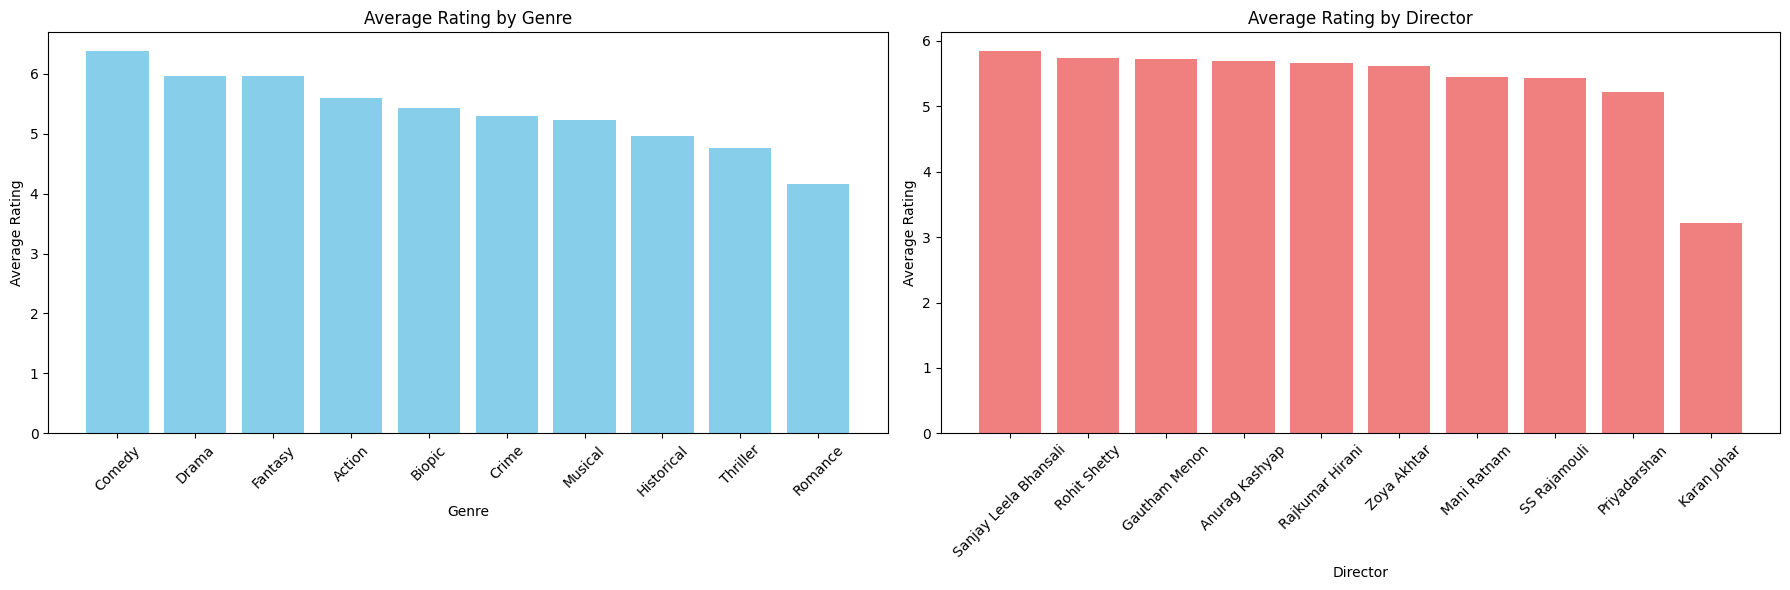

Bar plots for average rating by genre and director generated successfully.


In [33]:
import matplotlib.pyplot as plt

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6)) # One row, two columns

# Plot Average Rating by Genre
axes[0].bar(avg_rating_by_genre.index, avg_rating_by_genre.values, color='skyblue')
axes[0].set_xlabel('Genre')
axes[0].set_ylabel('Average Rating')
axes[0].set_title('Average Rating by Genre')
axes[0].tick_params(axis='x', rotation=45)

# Plot Average Rating by Director
axes[1].bar(avg_rating_by_director.index, avg_rating_by_director.values, color='lightcoral')
axes[1].set_xlabel('Director')
axes[1].set_ylabel('Average Rating')
axes[1].set_title('Average Rating by Director')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Bar plots for average rating by genre and director generated successfully.")

## Visualize Rating Trends Over Time

###
Create a line plot showing the average ratings over the years to display trends. Ensure the plot has appropriate labels, a title, and a legend.


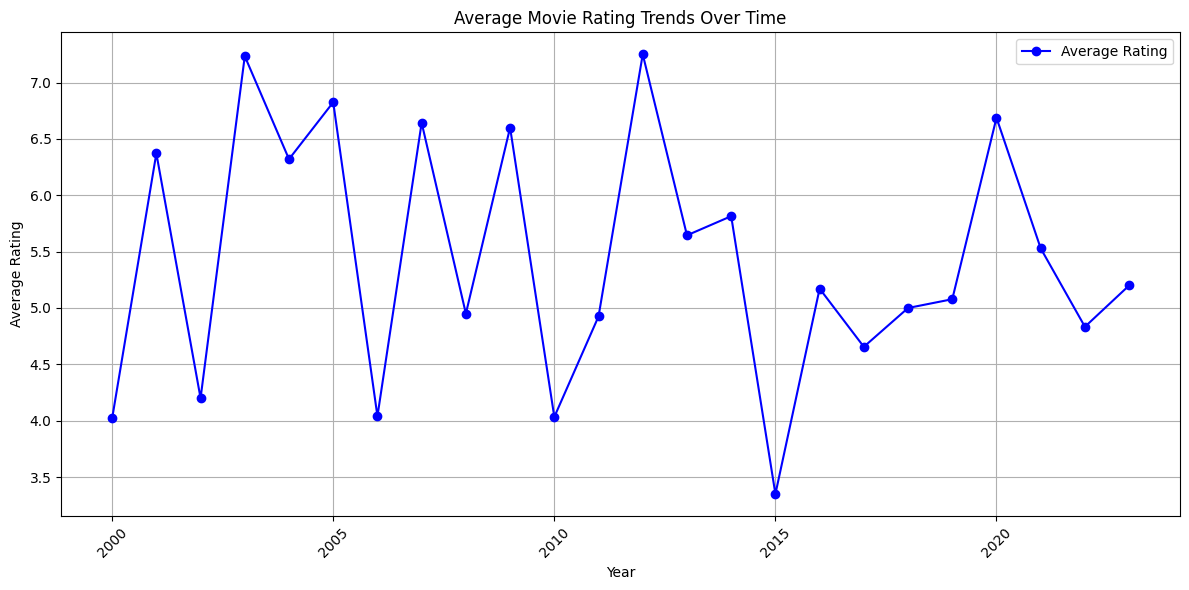

Line plot for average movie rating trends over time generated successfully.


In [34]:
plt.figure(figsize=(12, 6))
plt.plot(avg_rating_by_year.index, avg_rating_by_year.values, marker='o', linestyle='-', color='blue', label='Average Rating')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.title('Average Movie Rating Trends Over Time')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Line plot for average movie rating trends over time generated successfully.")

## Visualize Budget/Revenue vs. Rating

### Subtask:
Create a scatter plot to visualize the relationship between 'Budget' and 'Rating', and 'Revenue' and 'Rating'. Ensure both plots have clear titles, labels, and legends.

## Visualize Budget/Revenue vs. Rating

###
Create a scatter plot to visualize the relationship between 'Budget' and 'Rating', and 'Revenue' and 'Rating'. Ensure both plots have clear titles, labels, and legends.

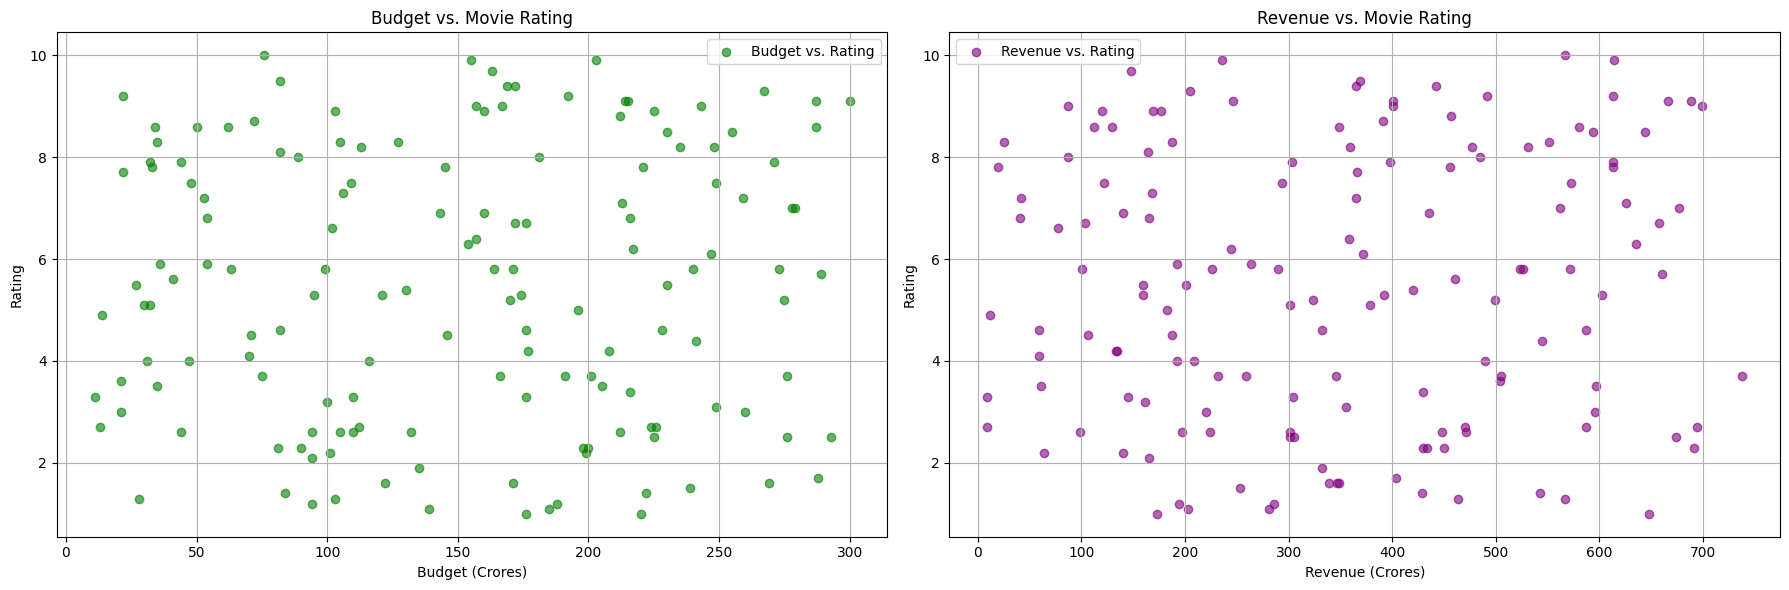

Scatter plots for Budget/Revenue vs. Rating generated successfully.


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Scatter plot for Budget vs. Rating
axes[0].scatter(df_movies['Budget'], df_movies['Rating'], alpha=0.6, color='green', label='Budget vs. Rating')
axes[0].set_xlabel('Budget (Crores)')
axes[0].set_ylabel('Rating')
axes[0].set_title('Budget vs. Movie Rating')
axes[0].grid(True)
axes[0].legend()

# Scatter plot for Revenue vs. Rating
axes[1].scatter(df_movies['Revenue'], df_movies['Rating'], alpha=0.6, color='purple', label='Revenue vs. Rating')
axes[1].set_xlabel('Revenue (Crores)')
axes[1].set_ylabel('Rating')
axes[1].set_title('Revenue vs. Movie Rating')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

print("Scatter plots for Budget/Revenue vs. Rating generated successfully.")

## Visualize Top-Rated Movies

###
Create a bar chart showing the top 10 movies by 'Rating'. Ensure the plot has clear titles, labels, and legends.

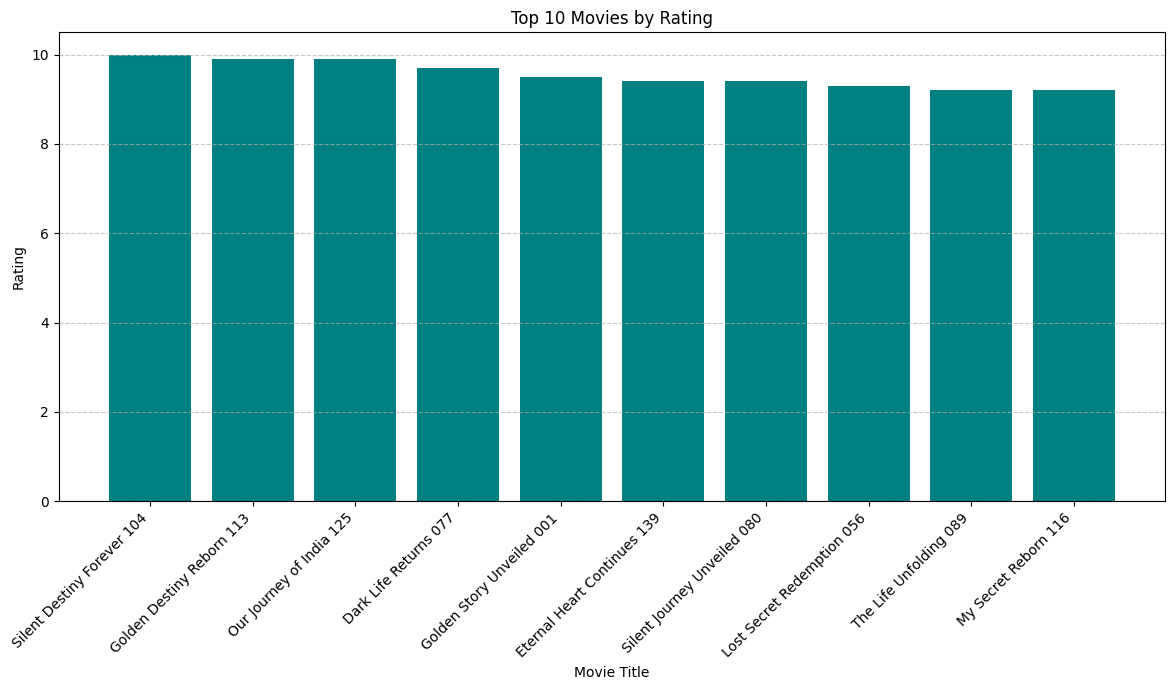

Bar chart for top 10 movies by rating generated successfully.


In [36]:
top_10_movies = df_movies.sort_values(by='Rating', ascending=False).head(10)

plt.figure(figsize=(12, 7))
plt.bar(top_10_movies['Title'], top_10_movies['Rating'], color='teal')
plt.xlabel('Movie Title')
plt.ylabel('Rating')
plt.title('Top 10 Movies by Rating')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Bar chart for top 10 movies by rating generated successfully.")